# ***Modèle numérique d'un bassin d'algues soumis à un mélange par une roue à aube.***

Le bassin est circulaire, de circonférence $L$. Il est ici représenté par un plan discrétisé en $N$ couches horizontales de mêmes dimensions. Dans chacune de ces couches nous cherchons à approximer la concentration en algues par une fonction du temps et de $x$, régie par une équation de diffusion. La périodicité s'impose comme condition aux bords (car le bassin est circulaire) mais la présence de la roue à aube apporte une difficulté supplémentaire. Celle-ci est modélisée par une matrice $P$ de transposée stochastique. D'autres conditions limites sont nécessaires : conservation de la masse, vecteur des concentrations en la roue à aube égal à un vecteur propre de $P$.

In [1]:
from modèle import *
from visualisation import *
from IPython.display import HTML
%load_ext autoreload
%autoreload 2

In [2]:
N = 3  # nombre de couches
L = 5  # longueur du bassin
H = 1  # hauteur du bassin
nb_colonnes_default = 50  # discrétisation horizontale
D = 1e-5  # coefficient de diffusion
T = 300  # temps final pour 20 tours
CFL = 1 / 4  # facteur entrant en compte dans la condition CFL

Id = np.identity(N)
P = np.matrix([[0, 1 / 2, 1], [1 / 2, 0, 0], [1 / 2, 1 / 2, 0]])  # matrice de mélange

V = vecteur_propre(P)

## on considère ici le modèle uniquement diffusif
u = [0.0] * N

params = {
    "N": N,  # nombre de couches
    "L": L,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": 50,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": T,  # temps final pour 20 tours
    "CFL": 1/4,  # facteur CFL
    "u" : [0.0]*N,
    "I_s": 1500,
    "epsilon": 4.6,
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}

Pour initialiser notre bassin, il nous faut donner une concentration initiale pour chaque couche. Nous implémentons pour cela une fonction "bassin_initial" qui renvoie le bassin à l'instant $0$ et qui prend pour argument la fonction de $x$ et $y$ représentant la concentration initiale pour un bassin non discrétisé. Nous avons de plus défini deux autres fonctions, modèle_stochastique et solution_exacte_tronquee qui renvoient respectivement la solution approchée et la solution exacte étant donnée la fonction concentration initiale (vérifiant elle aussi les conditions aux bords). Modèle_stochatsique calcule le pas de temps $\Delta_t$ en fonction de la valeur du pas d'espace $\Delta_x$ de façon à vérifier la condition CFL. Ainsi, le temps final $T$ n'est pas nécessairement un multiple entier de $\Delta_t$. Il a donc fallu rajouter un pas de temps "final" plus petit pour calculer les valeurs de la solution approchée et de la solution exacte au même instant.

***Etudions la convergence du modèle cellulaire pour trois cas simples :*** un bassin à trois couches, des fonctions initiales correspondant aux fonctions propres du système. Nous nous limitons au cas où les coefficients $\alpha_{2k}, \beta_{2k}^i, \gamma_{2k+1}^i$ sont non nuls si et seulement si $k = 1$.

In [4]:
def f(x, y, N, l, h, p, alpha, beta, gamma):
    V = vecteur_propre(p)
    N_max = len(alpha)
    for i in range(N):
        if y >= i * h / N and y < (i + 1) * h / N:
            return sum(
                alpha[k] * V[i] * np.cos(2 * k * np.pi * x / l)
                + beta[i][k] * np.sin(2 * k * np.pi * x / l)
                + gamma[i][k] * np.sin((2 * k + 1) * np.pi * x / l)
                for k in range(N_max)
            )

Exemple de solutions approchées pour la ligne $1$ avec différentes valeurs de $\Delta_x$ à l'instant $T$. Nous prenons pour fonction initiale la fonction propre telle que :
 $\\ \alpha_{2k} = 0, \ \beta_{2k}^i = 0, \ \gamma_{3}^1 = \gamma_{3}^2 = 1$ et $\gamma_{3}^3 = -2$.

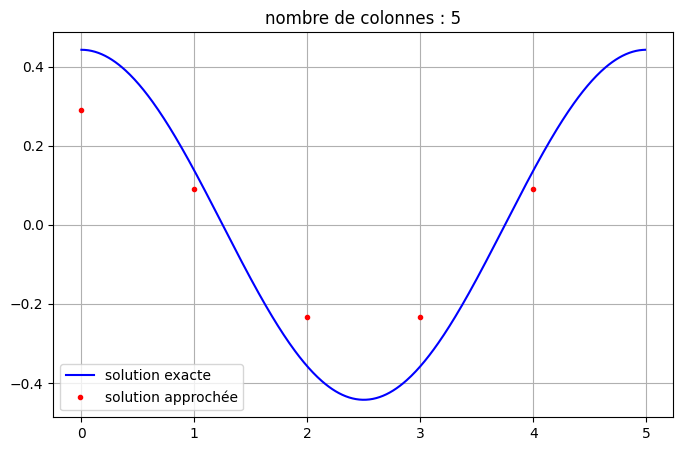

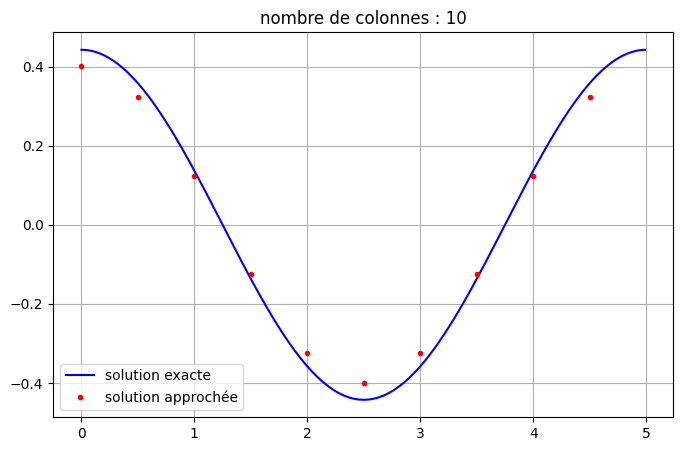

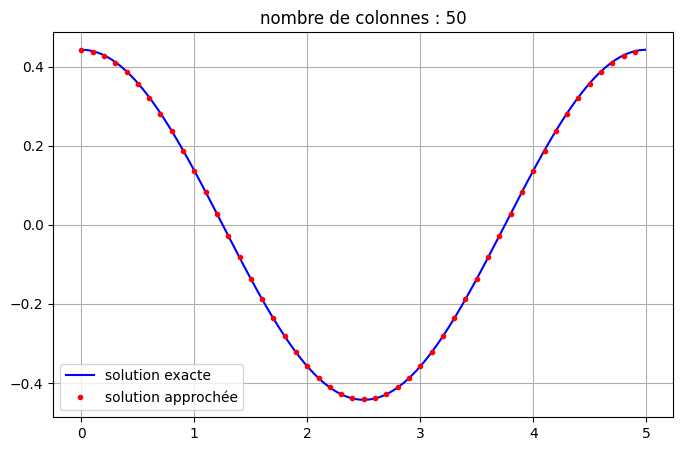

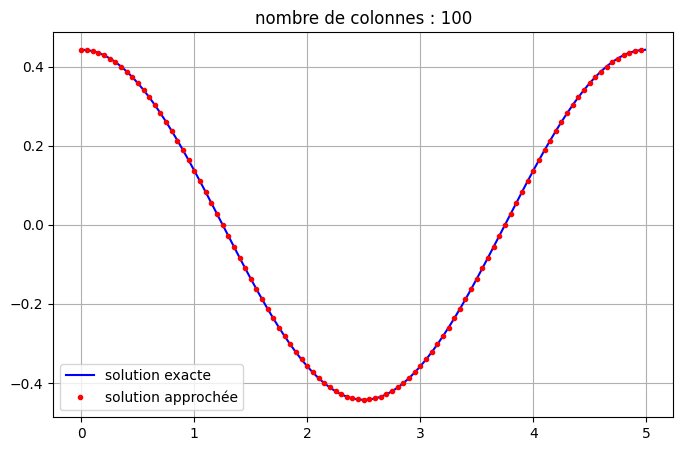

In [24]:
for nb_colonnes in [5, 10, 50, 100]:
    graphe_temps_final(
        1,  # ligne
        f,  # fonction initiale
        T,  # temps_final
        N,  # nombre de lignes
        nb_colonnes,  # nombre de colonnes
        P,  # matrice
        L,
        H,
        D,
        u,
        CFL,
        [0, 1, 0],
        [[0, 0, 0]] * N,
        [[0, 0, 0]] * N,
    )

Nous cherchons à vérifier que le modèle a une convergence d'ordre 2 en espace. Commençons par étudier sa convergence à temps fixé.

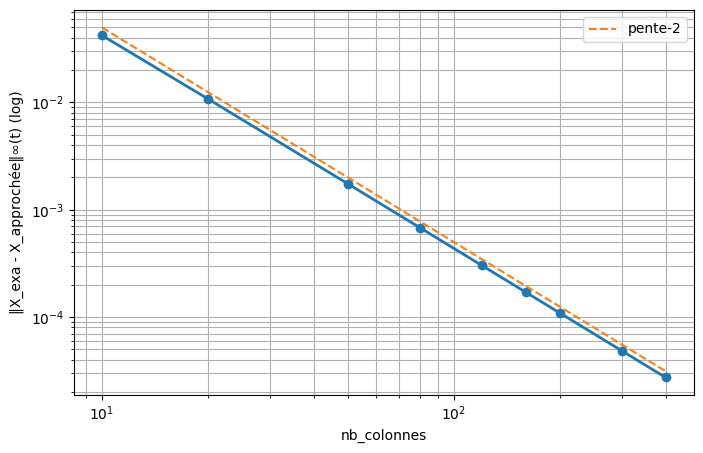

In [25]:
nb_colonnes_vals = [10, 20, 50, 80, 120, 160, 200, 300, 400]
graphe_convergence_a_t_fixe(
    f,  # fonction initiale
    T,  # temps_final
    N,
    P,
    L,
    H,
    D,
    u,
    CFL,
    [0, 1],
    [[0, 0]] * N,
    [[0, 0]] * N,
    nb_colonnes_vals,
)

La droite en pointillés nous donne simplement l'allure d'une fonction affine de pente $-2$ pour comparaison. Le graphe ci-dessus prend pour fonction initiale la fonction propre telle que :
 $\\ \alpha_{2} = 1, \ \beta_{2k}^i = 0, \ \gamma_{2k+1}^i = 0 \\$ Par la suite, nous étudierons uniquement des formes simples de fonctions propres, définies par les valeurs des variables aplha, beta et gamma prises pour argument par les fonctions de représentation de graphe. 

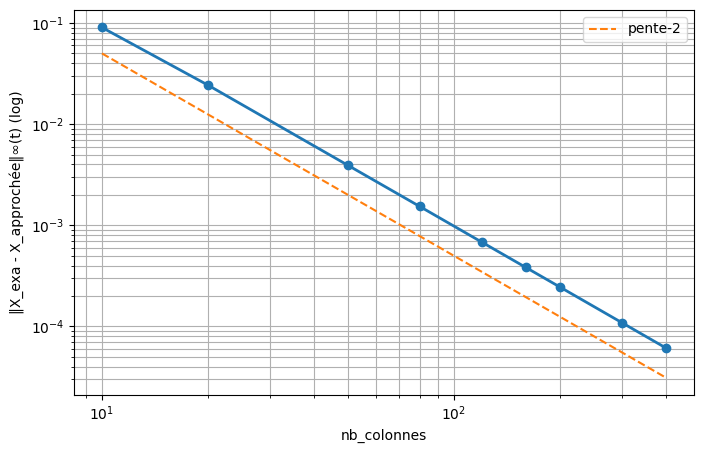

In [26]:
graphe_convergence_a_t_fixe(
    f,  # fonction initiale
    T,  # temps_final
    N,
    P,
    L,
    H,
    D,
    u,
    CFL,
    [0, 0],
    [[0, 1]] * N,
    [[0, 0]] * N,
    nb_colonnes_vals,
)

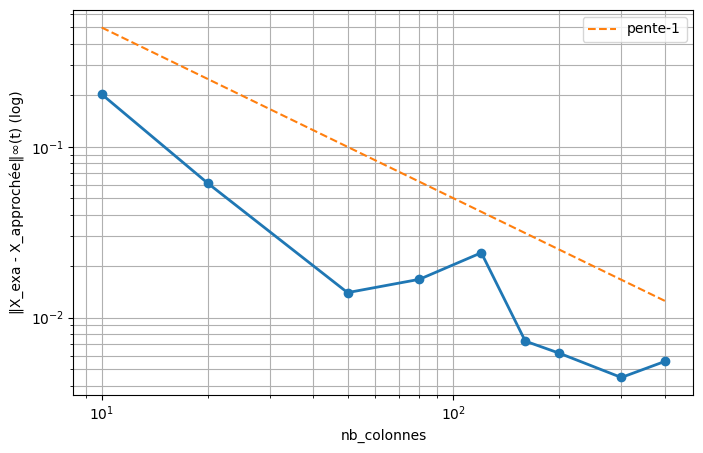

In [27]:
nb_colonnes_vals = [10, 20, 50, 80, 120, 160, 200, 300, 400]
graphe_convergence_a_t_fixe(
    f,  # fonction initiale
    T,  # temps_final
    N,
    P,
    L,
    H,
    D,
    u,
    CFL,
    [0, 0],
    [[0, 0]] * N,
    [[0, 1], [0, -1], [0, 0]],
    nb_colonnes_vals,
    -1,
)

Pour la fonction propre ayant des coefficients $\gamma$ non nuls (mais de somme nulle), nous remarquons que la convergence est d'ordre inférieur à 2. Il reste à déterminer pourquoi.

Etudions à présent la convergence en norme infinie (en temps et en espace).

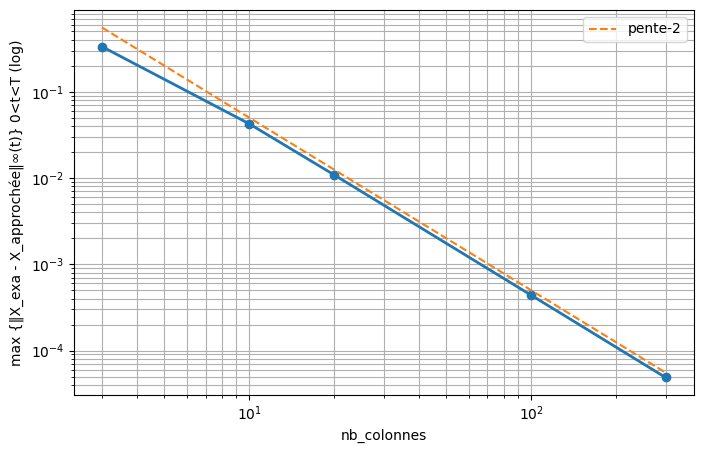

In [28]:
nb_colonnes_vals = [3, 10, 20, 100, 300]
graphe_convergence_norme_inf_en_temps(
    f,  # fonction initiale
    T,  # temps_final
    N,
    P,
    L,
    H,
    D,
    u,
    CFL,
    [0, 1],
    [[0, 0]] * N,
    [[0, 0]] * N,
    nb_colonnes_vals,
)

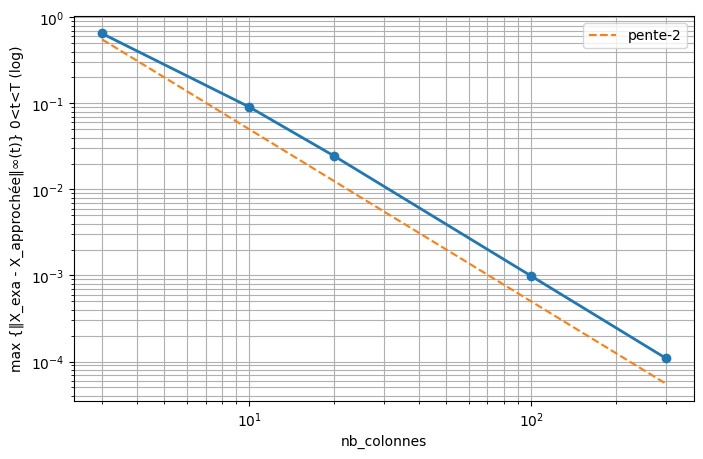

In [29]:
graphe_convergence_norme_inf_en_temps(
    f,  # fonction initiale
    T,  # temps_final
    N,
    P,
    L,
    H,
    D,
    u,
    CFL,
    [0, 0],
    [[0, 1]] * N,
    [[0, 0]] * N,
    nb_colonnes_vals,
)

***La convergence du schéma pour ces fonctions initiales est bien d'ordre 2.***

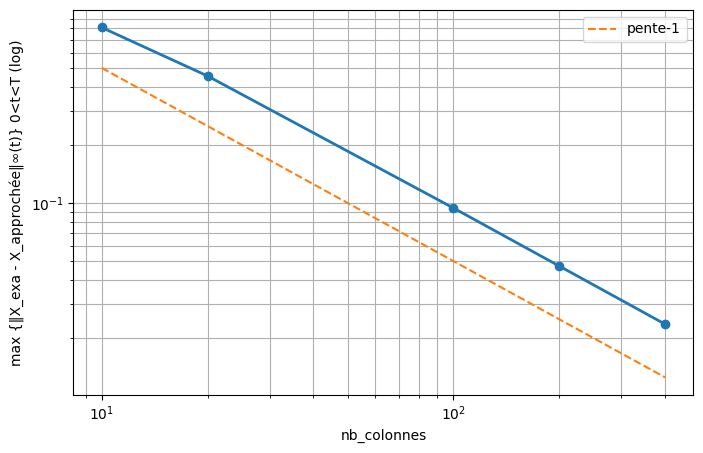

In [30]:
nb_colonnes_vals = [10, 20, 100, 200, 400]
graphe_convergence_norme_inf_en_temps(
    f,  # fonction initiale
    T,  # temps_final
    N,
    P,
    L,
    H,
    D,
    u,
    CFL,
    [0, 0],
    [[0, 0]] * N,
    [[0, 1], [0, 1], [0, -2]],
    nb_colonnes_vals,
    -1,
)

Ajoutons à présent le transport dans l'équation.

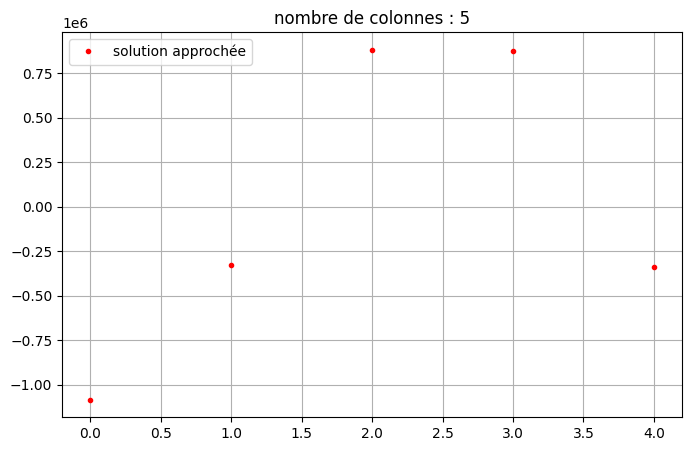

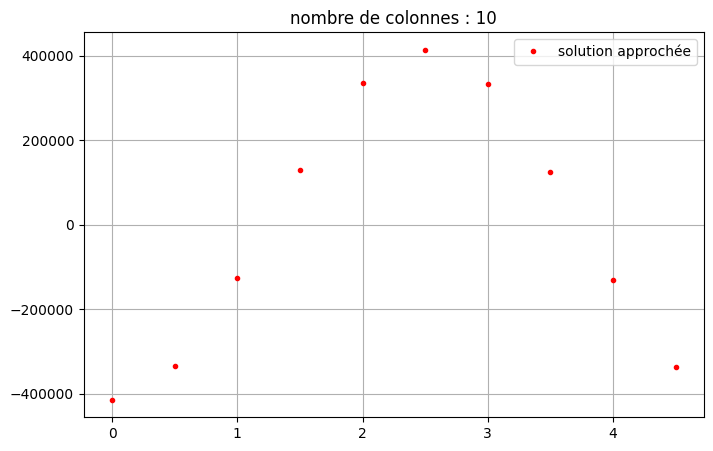

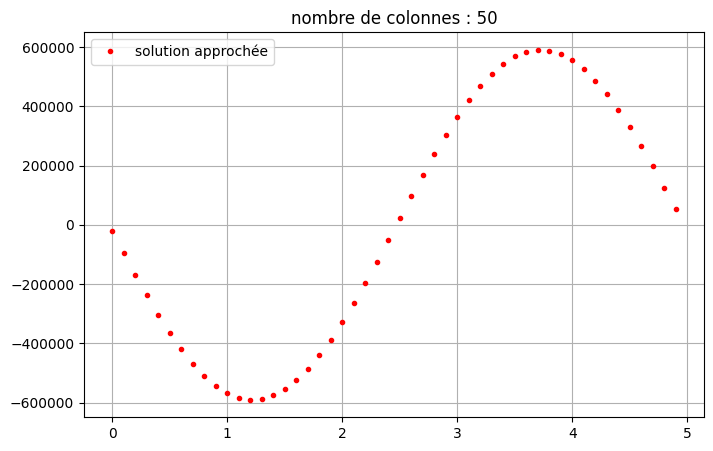

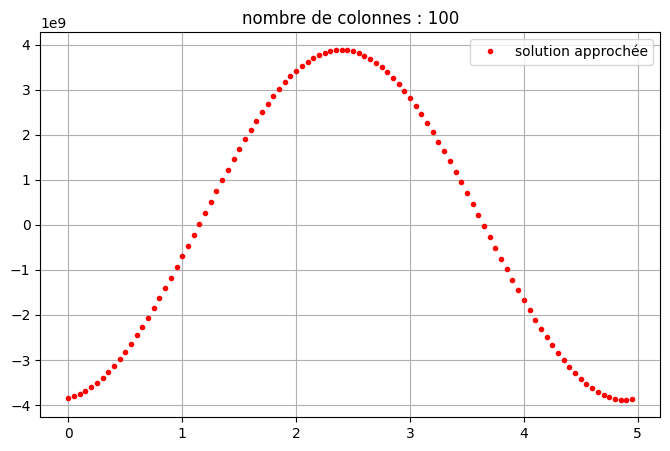

In [31]:
u = [0.3] * N

for nb_colonnes in [5, 10, 50, 100]:
    graphe_temps_final(
        1,  # ligne
        f,  # fonction initiale
        T,  # temps_final
        N,  # nombre de lignes
        nb_colonnes,  # nombre de colonnes
        P,  # matrice
        L,
        H,
        D,
        u,
        CFL,
        [0, 1, 0],
        [[0, 0, 0]] * N,
        [[0, 0, 0]] * N,
        False
    )

# ***Optimisation du modèle***

In [11]:
CFL = 0.95
u = [0.1]*N #vitesse faible, c'est vrai ... mais ça diminue énormément le temps de calcul 


params = {
    "N": 3,  # nombre de couches
    "L": 5,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": nb_colonnes_default,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": 300,  # temps final pour 20 tours
    "CFL": 0.95,  # facteur CFL
    "u" : [0.1]*N,
    "epsilon": 4.6,
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}



Graphes de $\mu$ en fonction de $z \in [0, H]$ et $I$ en fonction de $I \in [0, I_s]$.

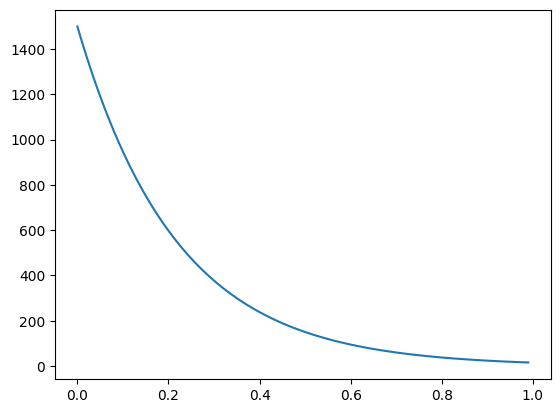

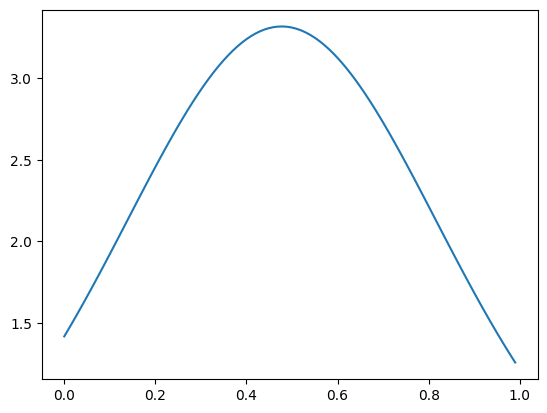

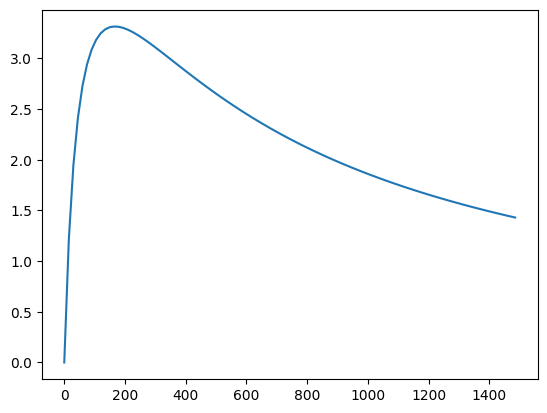

In [33]:
H = 1
z_list = [k*H/100 for k in range(100)]
I_list = [k*I_s/100 for k in range(100)]

mu_list_en_fonction_z = []
for z in z_list:
    I = I_s*np.exp(-epsilon*z)
    A = 1/((k_d/k_r)*tau*(sigma_H*I)**2 + tau*sigma_H*I + 1)
    taux_croiss = k_h*sigma_H*I*A
    mu_list_en_fonction_z.append(1e5*taux_croiss)

mu_list_en_fonction_I = []
for I in I_list:
    A = 1/((k_d/k_r)*tau*(sigma_H*I)**2 + tau*sigma_H*I + 1)
    taux_croiss = k_h*sigma_H*I*A
    mu_list_en_fonction_I.append(1e5*taux_croiss)

I_list_en_fonction_z = []
for z in z_list:
    I = I_s*np.exp(-epsilon*z)
    I_list_en_fonction_z.append(I)

plt.plot(z_list, I_list_en_fonction_z)
plt.show()

plt.plot(z_list, mu_list_en_fonction_z)
plt.show()

plt.plot(I_list, mu_list_en_fonction_I)
plt.show()

Avant d'ajouter un terme source à notre schéma, passons d'abord à une discrétisation décentrée du transport. Vérifions que le schéma décentré est bien stable pour sa nouvelle condition CFL : $ \Delta_t \leq \frac{\Delta_x^2}{2\mu + a\Delta_x}$

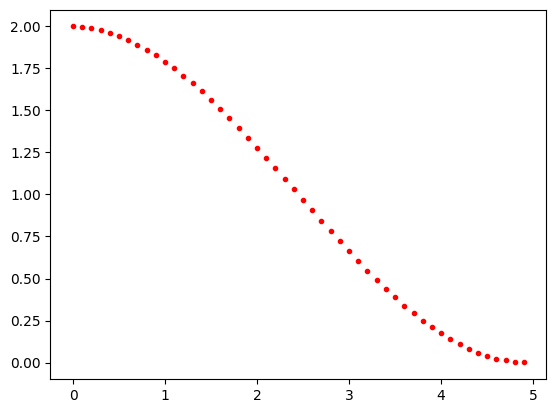

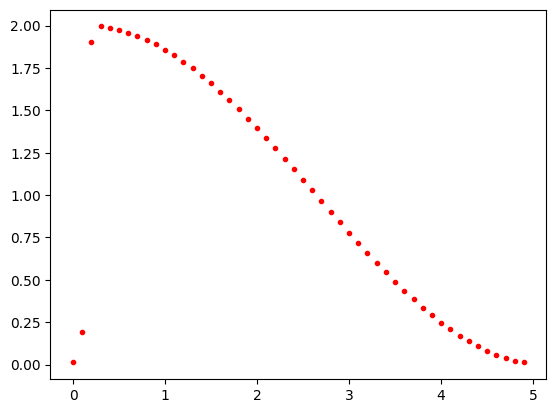

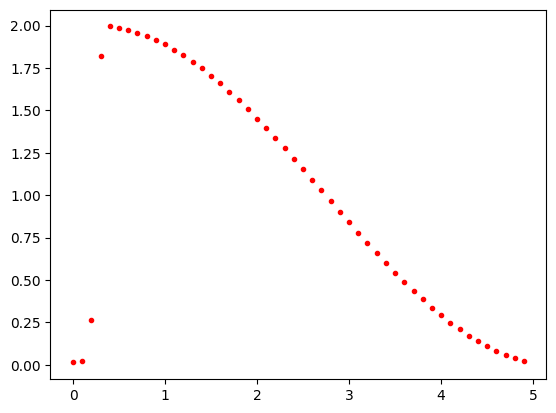

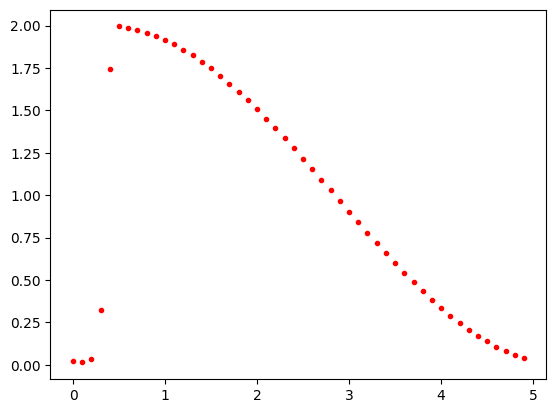

In [57]:
N=1
u = [0.1]*N
for t in range(4):
    X = modèle_stochastique(X_init(N, nb_colonnes_default, L), t, N, nb_colonnes_default, np.identity(N), L, H, D, u, 0.95, "advection_diffusion_décentrée")
    plt.plot([k*L/nb_colonnes_default for k in range(nb_colonnes_default)], X.flatten(), '.', color='red', label='solution approchée')
    plt.show()



Vérifions qu'il y a bien conservation de la masse :

In [ ]:
N=1
for t in range(4):
    X = modèle_stochastique(X_init(N, nb_colonnes_default, L), 10*t, N, nb_colonnes_default, np.identity(N), L, H, D, u, 0.95, "advection_diffusion_décentrée")
    masse_totale_algues = 0
    for ligne in X:
        for case in ligne :
            masse_totale_algues += case
    print(masse_totale_algues)

5
50.0
49.999999999999986
49.999999999999986
50.00000000000001


Nous ajoutons à présent un terme source. Il nous faut d'abord définir les variables entrant en jeu dans le modèle de Haldane. Pour ce qui est de la loi d'intensité (Beer-Lambert), nous simplifions le modèle en fixant une constante $\epsilon$ correspondant à l'absorbance d'un bassin d'algues réparties de manière homogène, avec une biomasse totale égale à celle de la configuration initiale. 
Nous faisons immédiatement face à un problème : $\Delta_t$ dépend de $\mu$, qui lui-même dépend de I. Il y a donc un pas de temps différent pour chaque couche. Nous approximons donc $\Delta_t$ par sa valeur pour une valeur moyenne de $\mu$.

In [40]:
f_de_x = 10
delta_x = L/nb_colonnes_default
delta_t = CFL * delta_x**2 / (2*D + abs(u[0])*delta_x)
print(f'delta_t : {delta_t}')
print(int(T/delta_t))
N=3

for i in range(3):
    I = I_s*np.exp(-epsilon*i*H/N)
    print(I)
    A = 1/(k_d/k_r*tau*(sigma_H*I)**2 + tau*sigma_H*I + 1)
    taux = A*I*k_h*sigma_H


print(f'total : {50*f_de_x}')


print(A*I*k_h*sigma_H)

delta_t : 0.3164556962025317
947
1500.0
323.7226250980347
69.86422533357515
total : 500
2.877681400880744e-05


Etudions l'évolution de la biomasse pour une couche simple, en fonction de la vitesse $u$.

In [ ]:
N=1

print(fonction_objectif(X_init(1, 50, L), 0, 1, 50, np.identity(1), L, H, D, [0], 0.95))
for u_test in [0.0, 0.1, 0.2, 0.3, 0.5]:
    print(fonction_objectif(X_init(1, 50, L), 3600, 1, 50, np.identity(1), L, H, D, [u_test], 0.95))

50.0
52.968154077957244
52.62275765217569
52.62241287264052
52.62229779270068
52.622205673732005
52.62213655232168
52.62210198151564
52.62209045548676


Il semble que plus le courant est important, plus le taux de croissance est faible. Essayons à présent pour un nombre de couches supérieur.

In [43]:
N=3
print(fonction_objectif(X_init(N, 50, L), 0, N, 50, np.identity(N), L, H, D, [0], 0.95))
for u_test in [0.0, 0.1, 0.2, 0.3, 0.5]:
    print(fonction_objectif(X_init(N, nb_colonnes_default, L), 3600, N, nb_colonnes_default, np.identity(N), L, H, D, [u_test]*N, 0.95))

50.0
52.968154077957244
52.62275765217569
52.62241287264052
52.62229779270068
52.622205673732005


In [6]:
N=5
params["N"]=5
u = [0.1]*N
params["u"]=u

params["nb_colonnes_default"] = nb_colonnes_default
X = X_ini_one_layer(N, nb_colonnes_default)
masse_totale, M, liste_biomasses= meilleure_matrice_de_permutation(X, T, params)
print(M)


[[0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]]


In [8]:
print(liste_biomasses)
print(masse_totale)
print(params["epsilon"])

[np.float64(50.21360069443486), np.float64(50.287011035383856), np.float64(50.34766138455035), np.float64(50.21360069443486), np.float64(50.34929775404898), np.float64(50.3424631480218), np.float64(50.380182659012775), np.float64(50.37640321771109), np.float64(50.21360069443486), np.float64(50.374127494979554), np.float64(50.287011035383856), np.float64(50.21360069443486), np.float64(50.21360069443486), np.float64(50.3739477568964), np.float64(50.34236653255029), np.float64(50.21360069443486), np.float64(50.3424631480218), np.float64(50.37535510931498), np.float64(50.334342140408225), np.float64(50.37499565217332), np.float64(50.34376322179231), np.float64(50.334342140408225), np.float64(50.379942978719654), np.float64(50.37622349865083), np.float64(50.36761322748912), np.float64(50.379942978719654), np.float64(50.334342140408225), np.float64(50.34031507410339), np.float64(50.36534589031719), np.float64(50.334342140408225), np.float64(50.21360069443486), np.float64(50.341723726769374),

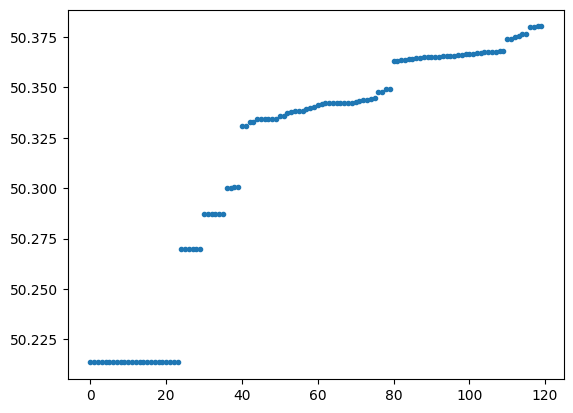

In [10]:
liste_biomasses = sorted(liste_biomasses)
plt.plot([k for k in range(120)], liste_biomasses, '.')

tableau des intensités lumineuses par couche

In [31]:
for i in range(5):
    I = I_s*np.exp(-epsilon*H/5*i)
    A = 1/(k_d/k_r*tau*(sigma_H*I)**2 + tau*sigma_H*I + 1)
    taux_croiss = k_h*sigma_H*I*A
    print(f'intensité : {I}')
    print(f'taux croiss : {taux_croiss}')

intensité : 1500.0
taux croiss : 1.4197932976820151e-05
intensité : 597.7785616267713
taux croiss : 2.4558381530676377e-05
intensité : 238.22613916038105
taux croiss : 3.237305992690618e-05
intensité : 94.9376525394611
taux croiss : 3.122920136988637e-05
intensité : 37.83446225284084
taux croiss : 2.215295308377659e-05


évolution de la masse par couche au cours du temps

In [11]:
params["u"]=[0.1]*N
X, masse_par_couche = modèle_stochastique(X_ini_one_layer(N, nb_colonnes_default), T, M, params, "advection_diffusion_terme_source")

ValueError: too many values to unpack (expected 2)

In [38]:
print(len(masse_par_couche[0]))

1203


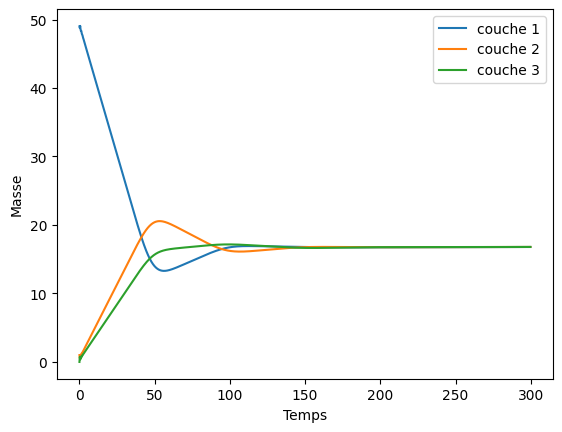

In [39]:
for i in range(N):
    plt.plot([k*T/len(masse_par_couche[0]) for k in range(len(masse_par_couche[0]))], masse_par_couche[i], label=f'couche {i+1}')

plt.xlabel("Temps")
plt.ylabel("Masse")
plt.legend()
plt.show()

In [6]:
N=3
for k in range(N):
    X = X_ini_one_layer(N, nb_colonnes_default, k)
    u = [0.1]*N
    masse_tot, M, liste_biomasses = meilleure_matrice_de_permutation(X, T, params)
    print(masse_tot, M)

50.309653317582196 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
50.65200655763834 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
50.61487185706934 [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [55]:
N = 3
def f1(x, y):
    return (...)


X = X_init(N, nb_colonnes_default, L)
print(meilleure_matrice_de_permutation(X, T, N, nb_colonnes_default, L, H, D, u, CFL))


(np.float64(50.144760458328875), array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]]), [np.float64(50.13839576125802), np.float64(50.14460683352324), np.float64(50.144760458328875), np.float64(50.13839576125802), np.float64(50.1441089823769), np.float64(50.14393723294102)])
